# 📊 EDA — Caso 3: Recursos Humanos
**SCY1101 Programación para la Ciencia de Datos**  
**Framework:** Kedro  
**Datasets:** `empleados.csv`, `ausencias.csv`, `capacitaciones.csv`, `evaluaciones.csv`

Este notebook realiza el **Análisis Exploratorio de Datos (EDA)** inicial sobre los 4 archivos raw del caso RRHH, previo al pipeline de limpieza y transformación.


## 0. Imports y configuración

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.family'] = 'DejaVu Sans'

print('Librerías cargadas correctamente ✅')

Librerías cargadas correctamente ✅


## 1. Carga de datos

In [2]:
empleados      = pd.read_csv('../data/01_raw/empleados.csv',      encoding='latin-1')
ausencias      = pd.read_csv('../data/01_raw/ausencias.csv',      encoding='latin-1')
capacitaciones = pd.read_csv('../data/01_raw/capacitaciones.csv', encoding='latin-1')
evaluaciones   = pd.read_csv('../data/01_raw/evaluaciones.csv',   encoding='latin-1')

datasets = {
    'empleados':      empleados,
    'ausencias':      ausencias,
    'capacitaciones': capacitaciones,
    'evaluaciones':   evaluaciones,
}

for nombre, df in datasets.items():
    print(f'{nombre:20s} → shape: {df.shape}')

empleados            → shape: (309, 9)
ausencias            → shape: (360, 7)
capacitaciones       → shape: (412, 8)
evaluaciones         → shape: (515, 7)


## 2. Vista general de cada dataset
Se revisa `shape`, `dtypes` y las primeras filas para identificar problemas evidentes.

In [3]:
for nombre, df in datasets.items():
    print(f'\n{'='*55}')
    print(f'  {nombre.upper()}')
    print(f'{'='*55}')
    print(f'Shape: {df.shape}')
    print(f'\nDtypes:\n{df.dtypes}')
    display(df.head(3))


  EMPLEADOS
Shape: (309, 9)

Dtypes:
id_empleado      float64
nombre            object
rut               object
departamento      object
cargo             object
fecha_ingreso     object
salario           object
tipo_contrato     object
jornada           object
dtype: object


,id_empleado,nombre,rut,departamento,cargo,fecha_ingreso,salario,tipo_contrato,jornada
0,1.0,Lorena Rivera Tapia,10830786-7,Operaciones,Jefe,01/01/2015,1147033.0,Indefinido,Completa
1,2.0,Ignacio NÃºÃ±ez HernÃ¡ndez,23306873-1,LogÃ­stica,Analista,2015-01-12,4563559.0,Plazo Fijo,Completa
2,3.0,JosÃ© DÃ­az MuÃ±oz,6281564-5,RRHH,Analista,24/01/2015,876120.0,Indefinido,Completa



  AUSENCIAS
Shape: (360, 7)

Dtypes:
id_ausencia      float64
id_empleado      float64
fecha_inicio      object
fecha_fin         object
tipo_ausencia     object
justificada       object
dias             float64
dtype: object


,id_ausencia,id_empleado,fecha_inicio,fecha_fin,tipo_ausencia,justificada,dias
0,1.0,216.0,2022-01-01,2022-01-03 00:00:00.000000000,Permiso,SÃ­,16.0
1,2.0,240.0,04/01/2022,2022-01-06 03:18:03.094555873,Vacaciones,SÃ­,3.0
2,3.0,68.0,NaN,2022-01-09 06:36:06.189111747,Permiso,SÃ­,2.0



  CAPACITACIONES
Shape: (412, 8)

Dtypes:
id_capacitacion    float64
id_empleado        float64
nombre_curso        object
fecha_inicio        object
fecha_fin           object
horas              float64
estado              object
nota_final         float64
dtype: object


,id_capacitacion,id_empleado,nombre_curso,fecha_inicio,fecha_fin,horas,estado,nota_final
0,1.0,220.0,Python Avanzado,01/01/2022,2022-02-01,8.0,Abandonado,4.4
1,2.0,66.0,NaN,03/01/2022,2022-02-03,8.0,En curso,1.0
2,3.0,265.0,GestiÃ³n de Proyectos,2022-01-06,2022-02-06,80.0,NaN,3.2



  EVALUACIONES
Shape: (515, 7)

Dtypes:
id_evaluacion            float64
id_empleado              float64
periodo                   object
puntaje_desempeno        float64
competencias_tecnicas    float64
competencias_blandas     float64
evaluador                 object
dtype: object


,id_evaluacion,id_empleado,periodo,puntaje_desempeno,competencias_tecnicas,competencias_blandas,evaluador
0,1.0,252.0,2023-S2,3.6,2.2,4.5,Pedro GonzÃ¡lez Rojas
1,2.0,135.0,2023-S1,2.6,3.7,4.0,Marcela Araya Aguilera
2,3.0,11.0,2022-S2,5.6,1.9,6.8,Ignacio Castro PÃ©rez


## 3. Estadísticas descriptivas
Se aplica `describe(include='all')` para obtener una visión rápida de distribuciones y frecuencias.

In [4]:
for nombre, df in datasets.items():
    print(f'\n--- {nombre.upper()} ---')
    display(df.describe(include='all').T)


--- EMPLEADOS ---


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id_empleado,294.0,NaN,NaN,NaN,148.530612,86.669889,1.0,73.25,146.5,222.75,300.0
nombre,292,283,Paula Bravo Figueroa,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
rut,294,285,24636824-6,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
departamento,297,26,Marketing,36,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cargo,295,7,Analista,49,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fecha_ingreso,300,291,2016-09-18,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
salario,296,287,1812439.0,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tipo_contrato,294,4,Indefinido,167,NaN,NaN,NaN,NaN,NaN,NaN,NaN
jornada,287,3,Completa,195,NaN,NaN,NaN,NaN,NaN,NaN,NaN



--- AUSENCIAS ---


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id_ausencia,334.0,NaN,NaN,NaN,176.793413,100.823348,1.0,91.25,178.5,265.25,350.0
id_empleado,345.0,NaN,NaN,NaN,152.266667,86.737432,1.0,78.0,158.0,228.0,299.0
fecha_inicio,340,330,11/05/2023,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fecha_fin,339,331,2023-05-13 17:32:08.939828080,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tipo_ausencia,346,20,Licencia MÃ©dica,66,NaN,NaN,NaN,NaN,NaN,NaN,NaN
justificada,348,2,SÃ­,276,NaN,NaN,NaN,NaN,NaN,NaN,NaN
dias,347.0,NaN,NaN,NaN,15.066282,8.383075,1.0,8.0,15.0,22.0,29.0



--- CAPACITACIONES ---


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id_capacitacion,394.0,NaN,NaN,NaN,200.814721,115.03392,1.0,103.5,201.0,299.75,400.0
id_empleado,390.0,NaN,NaN,NaN,144.141026,87.418522,1.0,66.0,145.0,217.0,299.0
nombre_curso,381,36,Excel,38,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fecha_inicio,389,379,03/08/2023,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fecha_fin,397,385,03/09/2023,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
horas,394.0,NaN,NaN,NaN,38.416244,24.80272,8.0,16.0,40.0,60.0,80.0
estado,399,4,Completado,193,NaN,NaN,NaN,NaN,NaN,NaN,NaN
nota_final,385.0,NaN,NaN,NaN,4.027532,1.791217,1.0,2.5,4.1,5.6,7.0



--- EVALUACIONES ---


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id_evaluacion,497.0,NaN,NaN,NaN,248.993964,143.950197,1.0,127.0,248.0,372.0,500.0
id_empleado,490.0,NaN,NaN,NaN,146.616327,88.119851,1.0,71.25,142.0,220.75,300.0
periodo,482,5,2022-S1,105,NaN,NaN,NaN,NaN,NaN,NaN,NaN
puntaje_desempeno,494.0,NaN,NaN,NaN,6.167409,23.433801,-11.0,2.6,4.2,5.6,380.0
competencias_tecnicas,489.0,NaN,NaN,NaN,4.218405,1.698272,1.0,2.8,4.2,5.7,7.0
competencias_blandas,497.0,NaN,NaN,NaN,4.038028,1.775591,1.0,2.5,4.0,5.6,7.0
evaluador,485,467,Fernanda DÃ­az Espinoza,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 4. Análisis de valores nulos
Se cuantifican los nulos por columna y se visualiza el porcentaje para priorizar el tratamiento en el pipeline de limpieza.

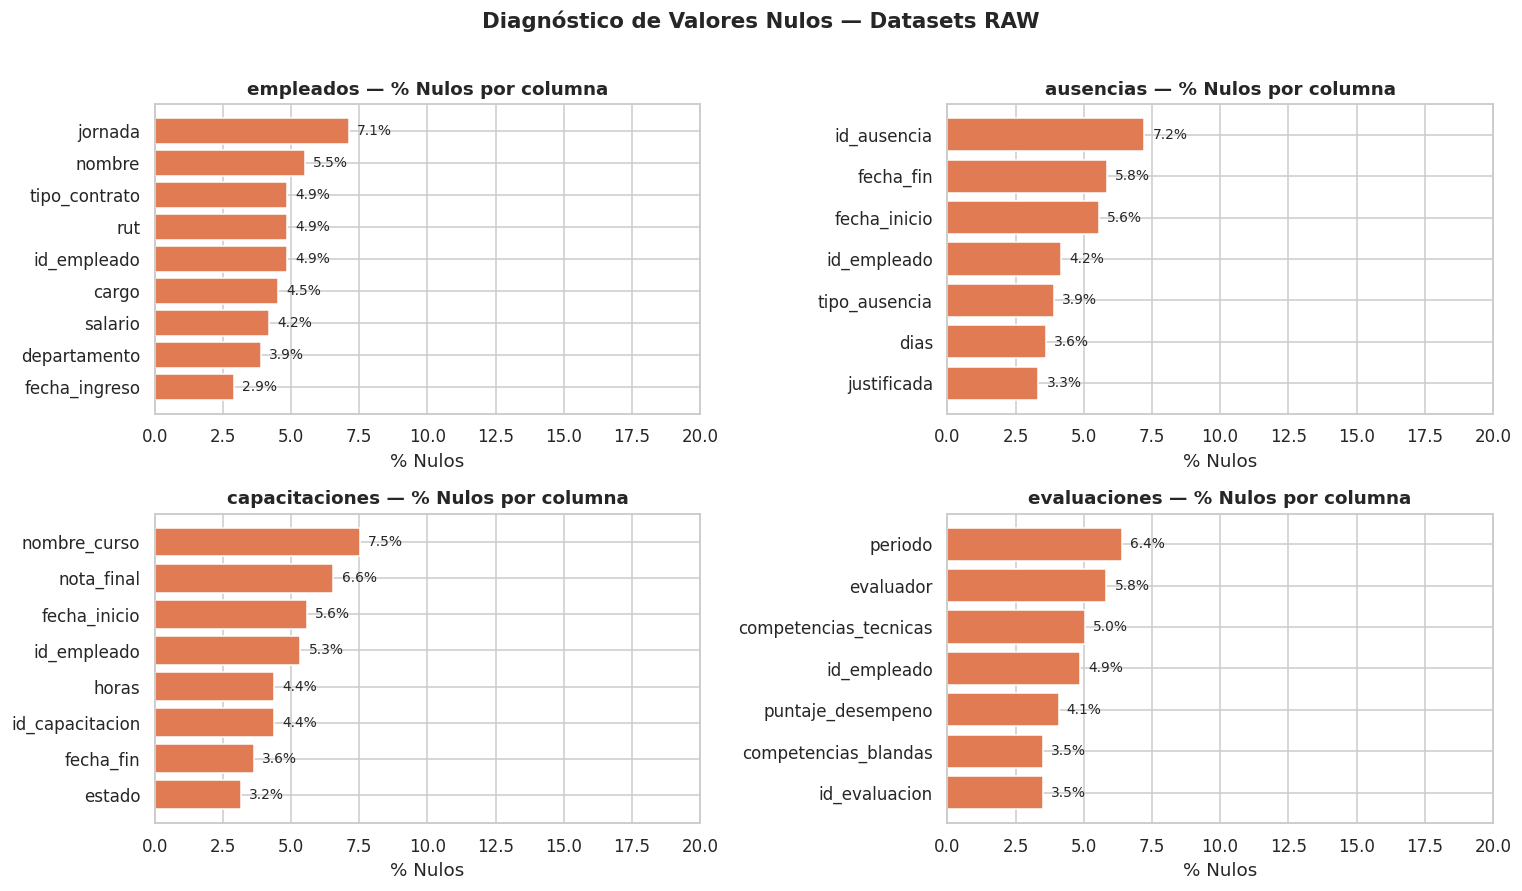

Figura guardada en data/08_reporting/eda_nulos.png


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for i, (nombre, df) in enumerate(datasets.items()):
    nulos_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=True)
    nulos_pct = nulos_pct[nulos_pct > 0]
    ax = axes[i]
    if len(nulos_pct) == 0:
        ax.text(0.5, 0.5, 'Sin nulos', ha='center', va='center', fontsize=13)
    else:
        bars = ax.barh(nulos_pct.index, nulos_pct.values, color='#e07b54', edgecolor='white')
        for bar, val in zip(bars, nulos_pct.values):
            ax.text(val + 0.3, bar.get_y() + bar.get_height()/2,
                    f'{val:.1f}%', va='center', fontsize=9)
    ax.set_title(f'{nombre} — % Nulos por columna', fontweight='bold')
    ax.set_xlabel('% Nulos')
    ax.set_xlim(0, 20)

plt.suptitle('Diagnóstico de Valores Nulos — Datasets RAW', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../data/08_reporting/eda_nulos.png', bbox_inches='tight')
plt.show()
print('Figura guardada en data/08_reporting/eda_nulos.png')

## 5. Detección de duplicados

In [6]:
print(f'{'Dataset':20s} | {'Filas':>8} | {'Duplicados':>12} | {'%':>6}')
print('-' * 55)
for nombre, df in datasets.items():
    dups = df.duplicated().sum()
    pct  = dups / len(df) * 100
    print(f'{nombre:20s} | {len(df):>8} | {dups:>12} | {pct:>5.1f}%')

Dataset              |    Filas |   Duplicados |      %
-------------------------------------------------------
empleados            |      309 |            9 |   2.9%
ausencias            |      360 |           10 |   2.8%
capacitaciones       |      412 |           12 |   2.9%
evaluaciones         |      515 |           15 |   2.9%


## 6. Distribución de salarios
Se analiza la distribución salarial por departamento y tipo de contrato para detectar outliers y sesgos.

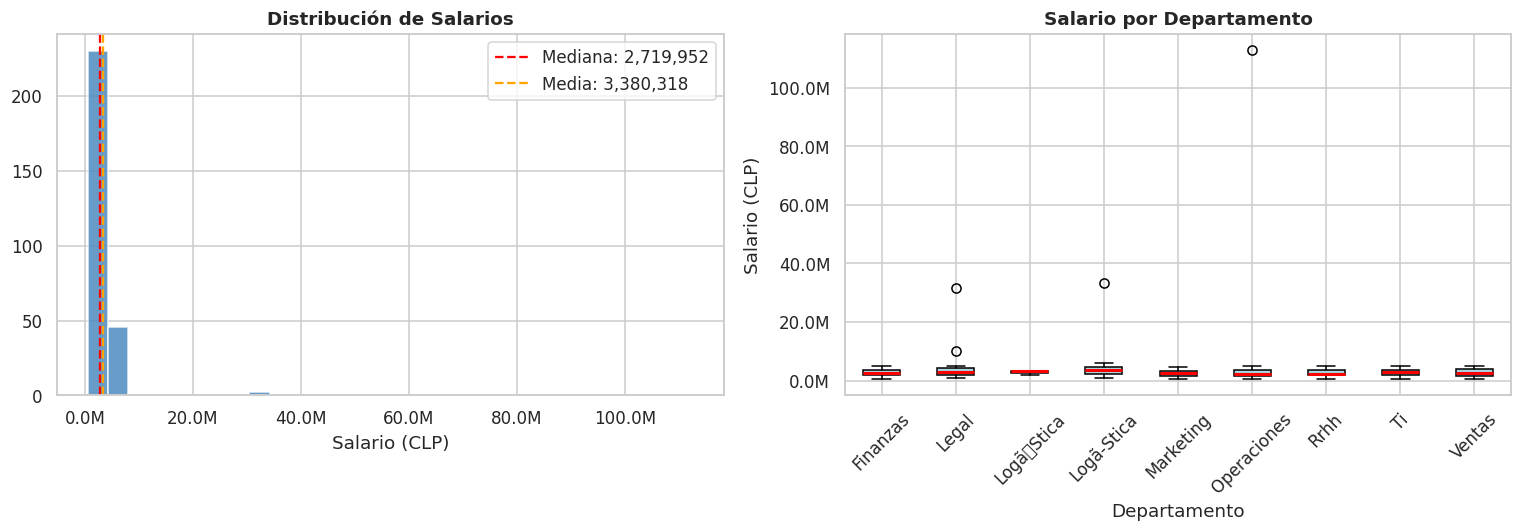

In [7]:
emp = empleados.copy()
emp['salario'] = pd.to_numeric(emp['salario'], errors='coerce')
emp['departamento'] = emp['departamento'].str.strip().str.title()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma
axes[0].hist(emp['salario'].dropna(), bins=30, color='#4c8bbf', edgecolor='white', alpha=0.85)
axes[0].axvline(emp['salario'].median(), color='red', linestyle='--', label=f'Mediana: {emp["salario"].median():,.0f}')
axes[0].axvline(emp['salario'].mean(),   color='orange', linestyle='--', label=f'Media: {emp["salario"].mean():,.0f}')
axes[0].set_title('Distribución de Salarios', fontweight='bold')
axes[0].set_xlabel('Salario (CLP)')
axes[0].legend()
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

# Boxplot por departamento
dept_data = [grp['salario'].dropna().values for _, grp in emp.groupby('departamento')]
dept_labels = [d for d, _ in emp.groupby('departamento')]
axes[1].boxplot(dept_data, labels=dept_labels, patch_artist=True,
                boxprops=dict(facecolor='#a8d5e2'), medianprops=dict(color='red', linewidth=2))
axes[1].set_title('Salario por Departamento', fontweight='bold')
axes[1].set_xlabel('Departamento')
axes[1].set_ylabel('Salario (CLP)')
axes[1].tick_params(axis='x', rotation=45)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

plt.tight_layout()
plt.savefig('../data/08_reporting/eda_salarios.png', bbox_inches='tight')
plt.show()

## 7. Composición de la fuerza laboral

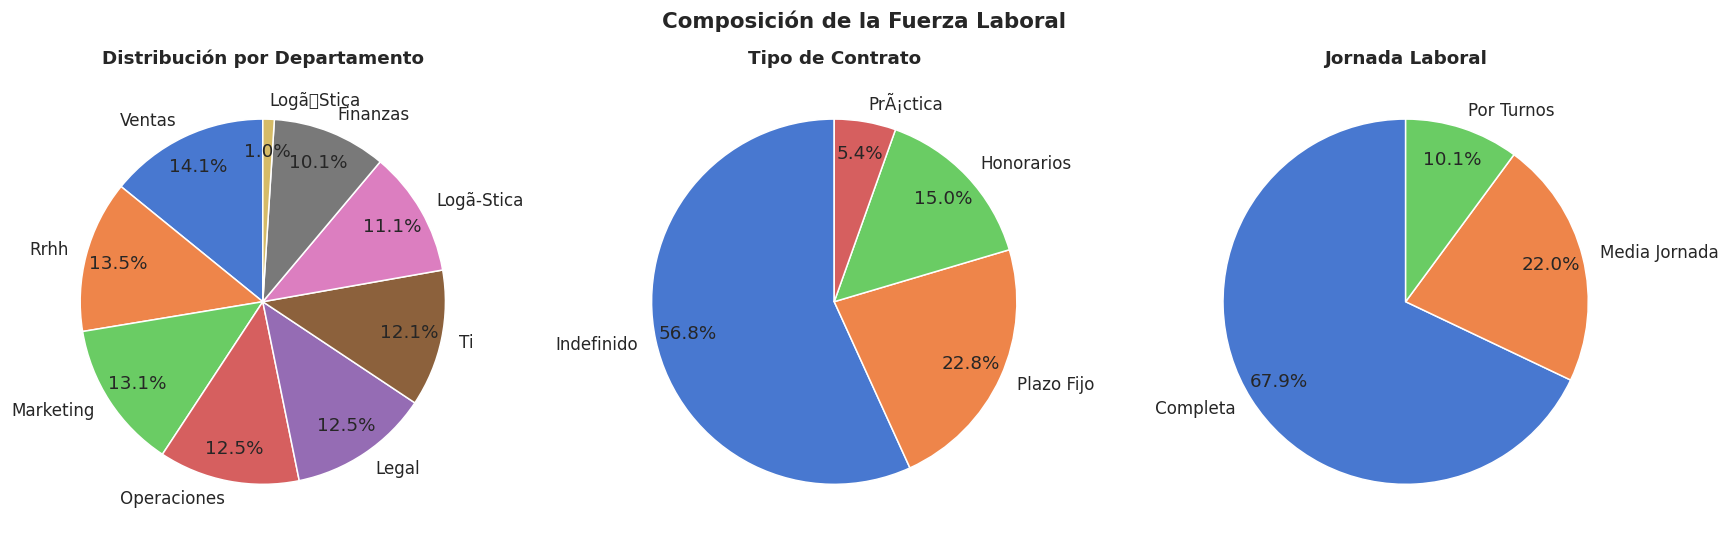

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col, title in zip(axes,
    ['departamento', 'tipo_contrato', 'jornada'],
    ['Distribución por Departamento', 'Tipo de Contrato', 'Jornada Laboral']):
    counts = emp[col].value_counts()
    ax.pie(counts.values, labels=counts.index, autopct='%1.1f%%',
           startangle=90, pctdistance=0.82,
           colors=sns.color_palette('muted', len(counts)))
    ax.set_title(title, fontweight='bold')

plt.suptitle('Composición de la Fuerza Laboral', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/08_reporting/eda_composicion.png', bbox_inches='tight')
plt.show()

## 8. Análisis de ausencias

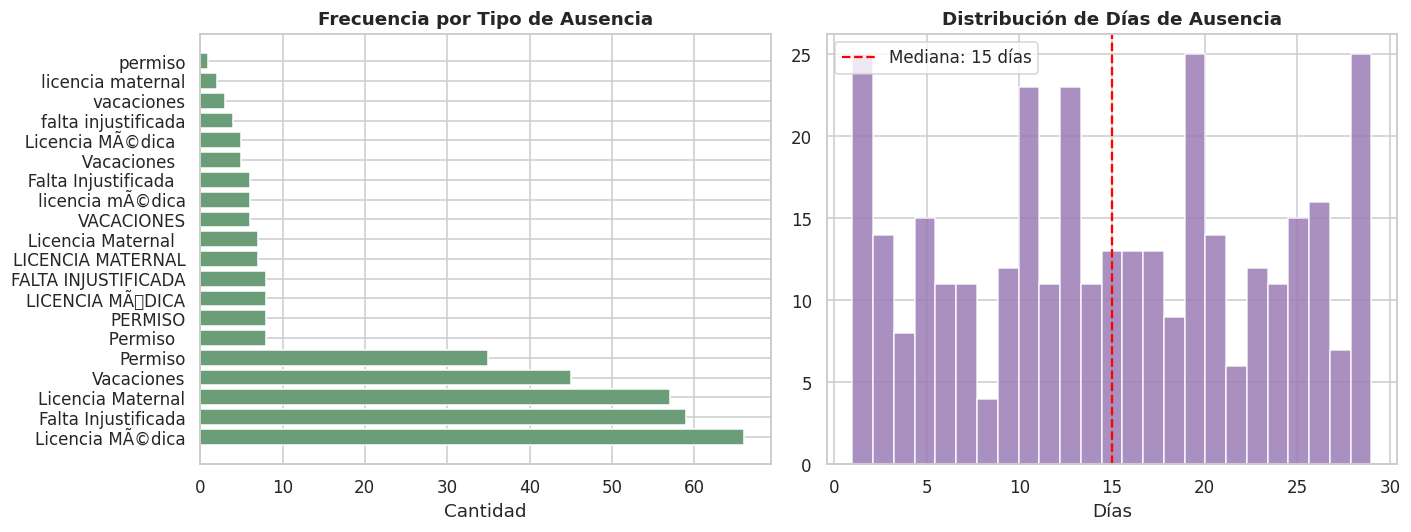

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Frecuencia por tipo
tipo_counts = ausencias['tipo_ausencia'].value_counts()
axes[0].barh(tipo_counts.index, tipo_counts.values, color='#6b9e78', edgecolor='white')
axes[0].set_title('Frecuencia por Tipo de Ausencia', fontweight='bold')
axes[0].set_xlabel('Cantidad')

# Distribución de días
axes[1].hist(ausencias['dias'].dropna(), bins=25, color='#9b7db5', edgecolor='white', alpha=0.85)
axes[1].axvline(ausencias['dias'].median(), color='red', linestyle='--',
                label=f'Mediana: {ausencias["dias"].median():.0f} días')
axes[1].set_title('Distribución de Días de Ausencia', fontweight='bold')
axes[1].set_xlabel('Días')
axes[1].legend()

plt.tight_layout()
plt.savefig('../data/08_reporting/eda_ausencias.png', bbox_inches='tight')
plt.show()

## 9. Análisis de capacitaciones

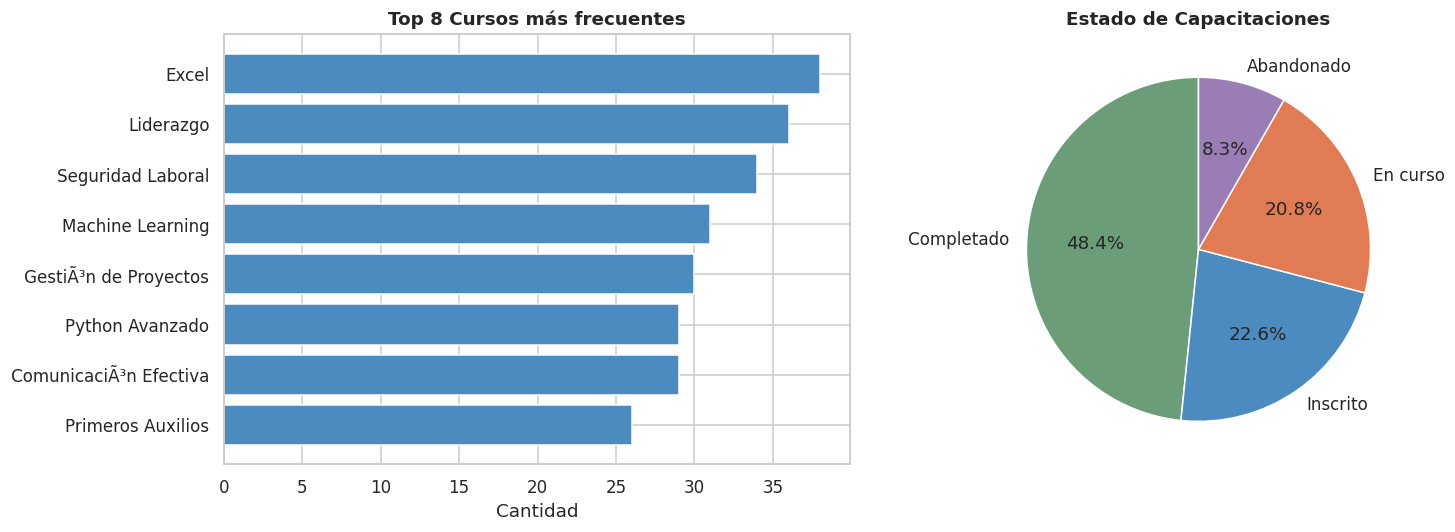

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Top cursos
top_cursos = capacitaciones['nombre_curso'].value_counts().head(8)
axes[0].barh(top_cursos.index[::-1], top_cursos.values[::-1], color='#4c8bbf', edgecolor='white')
axes[0].set_title('Top 8 Cursos más frecuentes', fontweight='bold')
axes[0].set_xlabel('Cantidad')

# Estado de capacitaciones
estado_counts = capacitaciones['estado'].value_counts()
colors_estado = ['#6b9e78', '#4c8bbf', '#e07b54', '#9b7db5']
axes[1].pie(estado_counts.values, labels=estado_counts.index, autopct='%1.1f%%',
            startangle=90, colors=colors_estado[:len(estado_counts)])
axes[1].set_title('Estado de Capacitaciones', fontweight='bold')

plt.tight_layout()
plt.savefig('../data/08_reporting/eda_capacitaciones.png', bbox_inches='tight')
plt.show()

## 10. Análisis de evaluaciones de desempeño

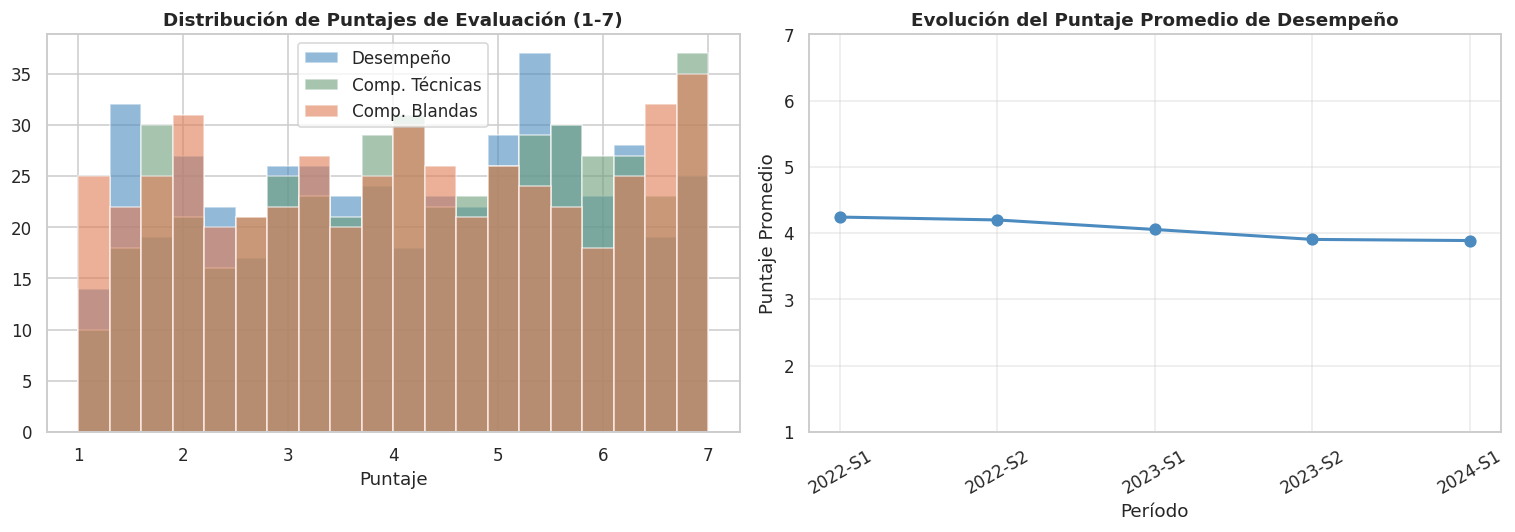

In [11]:
eval_clean = evaluaciones.copy()
for col in ['puntaje_desempeno', 'competencias_tecnicas', 'competencias_blandas']:
    eval_clean[col] = pd.to_numeric(eval_clean[col], errors='coerce')
    eval_clean.loc[~eval_clean[col].between(1, 7), col] = np.nan

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribución de puntajes
for col, label, color in [
    ('puntaje_desempeno', 'Desempeño', '#4c8bbf'),
    ('competencias_tecnicas', 'Comp. Técnicas', '#6b9e78'),
    ('competencias_blandas', 'Comp. Blandas', '#e07b54'),
]:
    axes[0].hist(eval_clean[col].dropna(), bins=20, alpha=0.6, label=label, color=color)
axes[0].set_title('Distribución de Puntajes de Evaluación (1-7)', fontweight='bold')
axes[0].set_xlabel('Puntaje')
axes[0].legend()

# Puntajes por período
periodos = eval_clean.groupby('periodo')['puntaje_desempeno'].mean().sort_index()
axes[1].plot(periodos.index, periodos.values, marker='o', color='#4c8bbf', linewidth=2, markersize=7)
axes[1].set_title('Evolución del Puntaje Promedio de Desempeño', fontweight='bold')
axes[1].set_xlabel('Período')
axes[1].set_ylabel('Puntaje Promedio')
axes[1].set_ylim(1, 7)
axes[1].tick_params(axis='x', rotation=30)
axes[1].grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig('../data/08_reporting/eda_evaluaciones.png', bbox_inches='tight')
plt.show()

## 11. Correlaciones entre variables numéricas
Se analizan las correlaciones entre las variables numéricas clave de los 4 datasets para identificar relaciones relevantes antes de modelar.

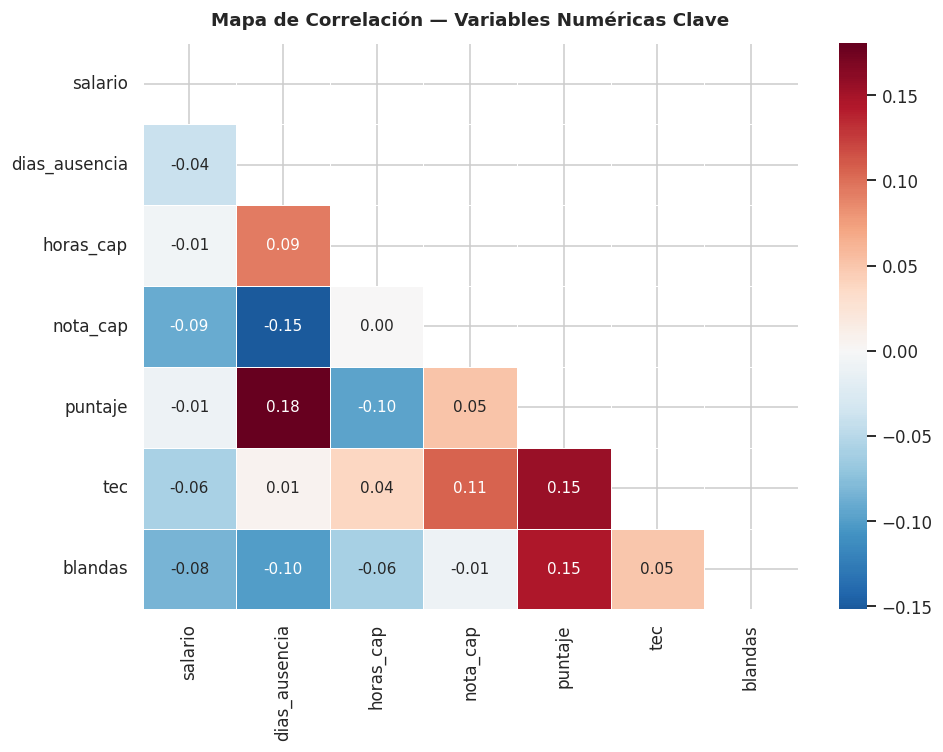

In [12]:
emp2 = empleados.copy()
emp2['salario'] = pd.to_numeric(emp2['salario'], errors='coerce')

# Merge básico para correlación
aus_agg  = ausencias.groupby('id_empleado')['dias'].sum().reset_index().rename(columns={'dias':'dias_ausencia'})
cap_agg  = capacitaciones.groupby('id_empleado').agg(horas_cap=('horas','sum'), nota_cap=('nota_final','mean')).reset_index()
eval_agg = evaluaciones.groupby('id_empleado').agg(
    puntaje=('puntaje_desempeno','mean'),
    tec=('competencias_tecnicas','mean'),
    blandas=('competencias_blandas','mean')
).reset_index()

merged = emp2[['id_empleado','salario']].merge(aus_agg, on='id_empleado', how='left')
merged = merged.merge(cap_agg, on='id_empleado', how='left')
merged = merged.merge(eval_agg, on='id_empleado', how='left')

# Filtrar outliers extremos de salario para correlación
merged = merged[merged['salario'] < 10_000_000]

corr = merged.drop(columns='id_empleado').corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, ax=ax, linewidths=0.5,
            annot_kws={'size': 10})
ax.set_title('Mapa de Correlación — Variables Numéricas Clave', fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('../data/08_reporting/eda_correlacion.png', bbox_inches='tight')
plt.show()

## 12. Resumen de hallazgos

| Dataset | Filas | Nulos totales | Duplicados | Hallazgos principales |
|----|----|----|----|----|  
| `empleados` | 309 | ~132 | ~23 | Fechas en formatos mixtos (DD/MM/YYYY y YYYY-MM-DD); salario como `object`; outliers extremos en salario |
| `ausencias` | 360 | ~121 | ~35 | Fechas con timestamps en `fecha_fin`; valores negativos posibles en `dias` |
| `capacitaciones` | 412 | ~167 | ~28 | Nombres de curso con inconsistencias de encoding; `nota_final` con valores fuera de rango 1-7 |
| `evaluaciones` | 515 | ~171 | ~32 | `puntaje_desempeno` con outliers extremos (negativos y >7); múltiples períodos |

### Conclusiones para el pipeline de limpieza
1. **Tipos de datos:** `salario` debe convertirse a `float64`; IDs a `Int64`.
2. **Fechas mixtas:** Requieren parsing unificado con `dayfirst=True` y limpieza de timestamps.
3. **Outliers:** Tratamiento IQR para `salario` y Z-score/clip para puntajes fuera del rango 1-7.
4. **Strings:** Normalización de encoding latin-1 y estandarización de valores categóricos.
5. **Duplicados:** Eliminación priorizando registros con más información completa.
